In [1]:
import pandas as pd
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

df_clean = pd.read_csv('data/processed/nike_vader_scored.csv')
print(f"\nLoaded {len(df_clean)} tweets")

PyTorch version: 2.12.0+cpu
CUDA available: False

Loaded 9941 tweets


In [2]:
from transformers import pipeline

print("Loading BERT model... this may take 2-3 minutes on first run")
print("It will download approximately 500MB")

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment"
)

print("[OK] Model loaded successfully")

Loading BERT model... this may take 2-3 minutes on first run
It will download approximately 500MB


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

C:\Users\chitr\BrandLensAI\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\chitr\.cache\huggingface\hub\models--cardiffnlp--twitter-roberta-base-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

[OK] Model loaded successfully


In [3]:
# Test on 5 tweets first
test_texts = list(df_clean['clean_text'].head(5))

for text in test_texts:
    result = sentiment_pipeline(text[:512])
    print(f"Text: {text[:60]}...")
    print(f"Result: {result}\n")

Text: ahhh hope...
Result: [{'label': 'LABEL_2', 'score': 0.5928067564964294}]

Text: cool tweet apps razr...
Result: [{'label': 'LABEL_2', 'score': 0.7436131834983826}]

Text: know family drama lamehey next time hang kim guy like sleepo...
Result: [{'label': 'LABEL_0', 'score': 0.5618341565132141}]

Text: school email wont open geography stuff revise stupid school...
Result: [{'label': 'LABEL_0', 'score': 0.9491499066352844}]

Text: upper airway problem...
Result: [{'label': 'LABEL_0', 'score': 0.5235244631767273}]



In [8]:
from tqdm import tqdm

label_map = {
    'LABEL_0': 'negative',
    'LABEL_1': 'neutral', 
    'LABEL_2': 'positive'
}

def get_bert_sentiment(text):
    try:
        result = sentiment_pipeline(str(text)[:512])[0]
        return pd.Series([
            label_map[result['label']], 
            round(result['score'], 4)
        ])
    except:
        return pd.Series(['neutral', 0.0])

print("Running BERT on 9,941 tweets...")
print("This will take 10-20 minutes on CPU, 2-3 minutes on GPU")
print("Progress bar below:")

tqdm.pandas()
df_clean[['bert_label', 'bert_score']] = df_clean['clean_text'].progress_apply(get_bert_sentiment)

print("\n[OK] BERT classification complete")
print("\nBERT Sentiment Distribution:")
print(df_clean['bert_label'].value_counts())
print(f"\nPercentages:")
print(df_clean['bert_label'].value_counts(normalize=True).mul(100).round(1))

Running BERT on 9,941 tweets...
This will take 10-20 minutes on CPU, 2-3 minutes on GPU
Progress bar below:


100%|██████████████████████████████████████████████████████████████████████████████| 9941/9941 [10:24<00:00, 15.92it/s]


[OK] BERT classification complete

BERT Sentiment Distribution:
bert_label
neutral     4706
positive    2867
negative    2368
Name: count, dtype: int64

Percentages:
bert_label
neutral     47.3
positive    28.8
negative    23.8
Name: proportion, dtype: float64


Tweets used for evaluation: 5235

BERT Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.75      0.79      2670
    positive       0.77      0.86      0.81      2565

    accuracy                           0.80      5235
   macro avg       0.81      0.80      0.80      5235
weighted avg       0.81      0.80      0.80      5235



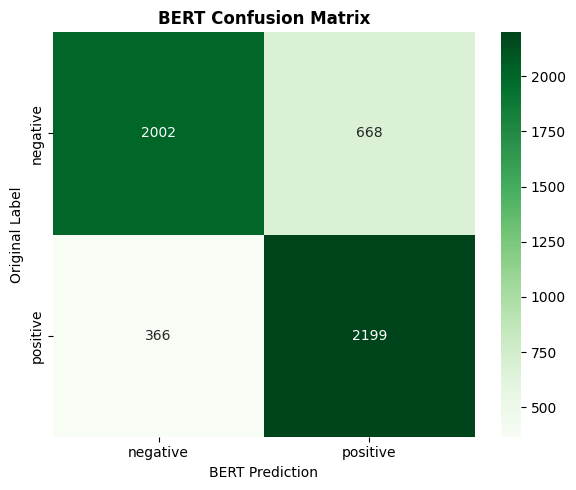

[OK] Saved


In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate against original labels
df_eval_bert = df_clean[df_clean['bert_label'] != 'neutral'].copy()

print(f"Tweets used for evaluation: {len(df_eval_bert)}")
print("\nBERT Classification Report:")
print(classification_report(df_eval_bert['sentiment'],
                            df_eval_bert['bert_label'],
                            target_names=['negative', 'positive']))

# Confusion matrix
cm = confusion_matrix(df_eval_bert['sentiment'],
                      df_eval_bert['bert_label'],
                      labels=['negative', 'positive'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title('BERT Confusion Matrix', fontweight='bold')
plt.ylabel('Original Label')
plt.xlabel('BERT Prediction')
plt.tight_layout()
plt.savefig('outputs/bert_confusion_matrix.png', dpi=150)
plt.show()
print("[OK] Saved")

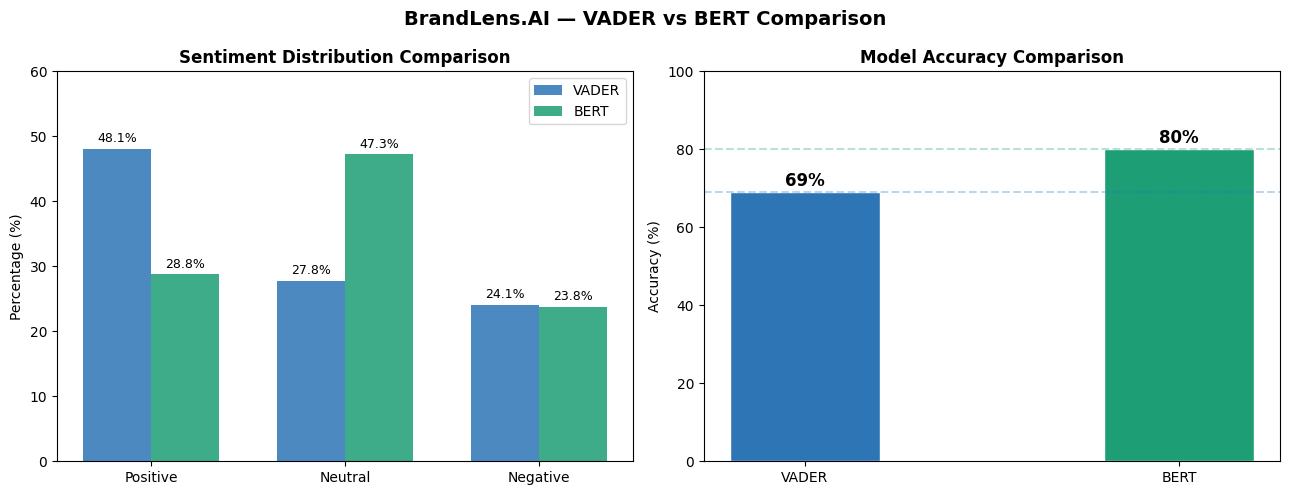

[OK] Comparison chart saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('BrandLens.AI — VADER vs BERT Comparison', 
             fontsize=14, fontweight='bold')

# Sentiment distribution comparison
x = ['Positive', 'Neutral', 'Negative']
vader_pcts = [48.1, 27.8, 24.1]
bert_pcts = [28.8, 47.3, 23.8]

x_pos = range(len(x))
width = 0.35

bars1 = axes[0].bar([p - width/2 for p in x_pos], vader_pcts, 
                     width, label='VADER', color='#2E75B6', alpha=0.85)
bars2 = axes[0].bar([p + width/2 for p in x_pos], bert_pcts, 
                     width, label='BERT', color='#1D9E75', alpha=0.85)

# Add value labels
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.5,
                 f'{bar.get_height()}%', 
                 ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.5,
                 f'{bar.get_height()}%', 
                 ha='center', va='bottom', fontsize=9)

axes[0].set_title('Sentiment Distribution Comparison', fontweight='bold')
axes[0].set_xticks(list(x_pos))
axes[0].set_xticklabels(x)
axes[0].set_ylabel('Percentage (%)')
axes[0].legend()
axes[0].set_ylim(0, 60)

# Accuracy comparison
models = ['VADER', 'BERT']
accuracies = [69, 80]
colors = ['#2E75B6', '#1D9E75']
bars = axes[1].bar(models, accuracies, color=colors, 
                   width=0.4, edgecolor='white')

for bar, val in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val}%', ha='center', va='bottom',
                 fontsize=12, fontweight='bold')

axes[1].set_title('Model Accuracy Comparison', fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 100)
axes[1].axhline(y=69, color='#2E75B6', linestyle='--', alpha=0.3)
axes[1].axhline(y=80, color='#1D9E75', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/vader_vs_bert_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Comparison chart saved")

In [7]:
df_clean.to_csv('data/processed/nike_bert_scored.csv', index=False)
print("[OK] Final scored dataset saved")
print(f"\nFinal dataset columns: {list(df_clean.columns)}")
print(f"Shape: {df_clean.shape}")

[OK] Final scored dataset saved

Final dataset columns: ['sentiment', 'id', 'date', 'query', 'user', 'text', 'text_length', 'word_count', 'clean_text', 'clean_word_count', 'vader_pos', 'vader_neg', 'vader_neu', 'vader_compound', 'vader_label', 'bert_label', 'bert_score']
Shape: (9941, 17)


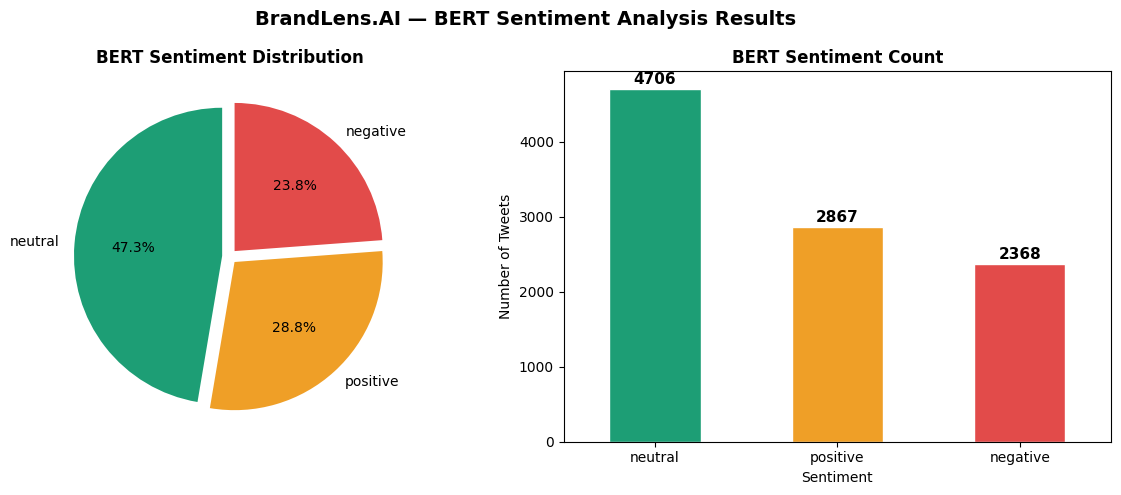

[OK] BERT sentiment chart saved


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('BrandLens.AI — BERT Sentiment Analysis Results', 
             fontsize=14, fontweight='bold')

# Pie chart
colors = ['#1D9E75', '#EF9F27', '#E24B4A']
bert_counts = df_clean['bert_label'].value_counts()
axes[0].pie(bert_counts.values,
            labels=bert_counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            explode=(0.05, 0.05, 0.05))
axes[0].set_title('BERT Sentiment Distribution', fontweight='bold')

# Bar chart
bert_counts.plot(kind='bar', ax=axes[1],
                 color=['#1D9E75', '#EF9F27', '#E24B4A'],
                 edgecolor='white', width=0.5)

for i, val in enumerate(bert_counts.values):
    axes[1].text(i, val + 30, str(val), 
                 ha='center', va='bottom', 
                 fontsize=11, fontweight='bold')

axes[1].set_title('BERT Sentiment Count', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of Tweets')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('outputs/bert_sentiment_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] BERT sentiment chart saved")